   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.7 MB/s eta 0:00:00
TensorFlow is using GPU: /device:GPU:0
Mounted at /content/drive
Test MSE: 0.0017, R²: 0.9765
Train MSE: 0.0003, R²: 0.9963


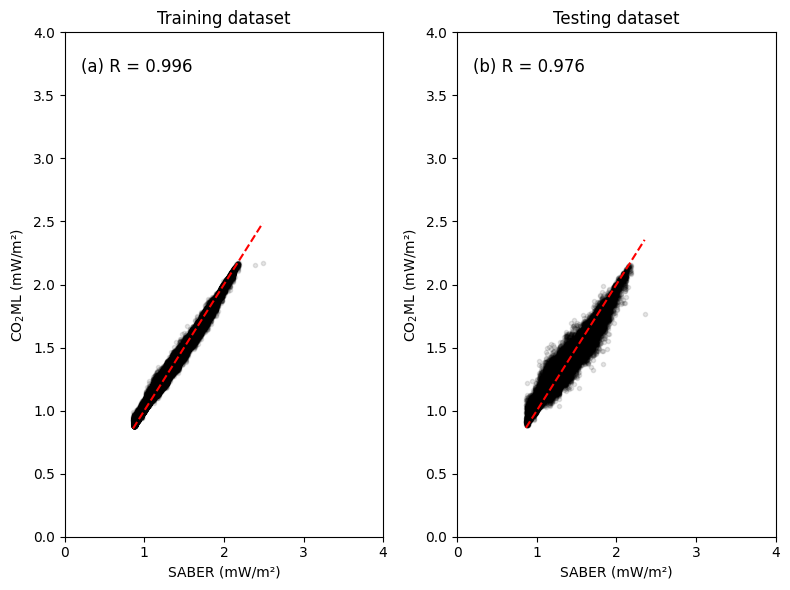

In [ ]:
%load_ext cudf.pandas
!pip install netCDF4
import numpy as np
import cudf
import cupy as cp
import os
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import netCDF4
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from cuml.ensemble import RandomForestRegressor
from cuml.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

device_name = tf.test.gpu_device_name()
if device_name:
    print(f"TensorFlow is using GPU: {device_name}")
else:
    print("TensorFlow is not using GPU. Check runtime settings.")

from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/CO2'
sbr = cudf.read_csv(f"{folder_path}/CO2_flux_1mnt_final_test.txt", sep="\t")
f107n = cudf.read_csv(f"{folder_path}/Omni1hr_to_1mnt.txt", sep="\t")
f107n['UT'] = (f107n['Hour'] * 60) + f107n['Minute']
fdata = cudf.DataFrame({
    "Year": f107n['Year'].astype(int),
    "Day": f107n['Day'].astype(int),
    "UT": f107n['UT'],
    "F107": f107n['F107']
})

co2n = cudf.read_csv(f"{folder_path}/OMNI_CO2_flux_1mnt_final.txt", sep="\t")
co2n['mean_ALT'] = co2n[['ALT_100', 'ALT_103', 'ALT_105', 'ALT_107']].mean(axis=1)
co2n['mean_Dst'] = co2n[['SYM', 'Dst']].mean(axis=1)
co2n['mean_AE'] = co2n[['AE', 'SME']].mean(axis=1)

co2n.drop(columns=['ALT_95', 'ALT_100', 'ALT_103', 'ALT_105', 'ALT_107', 'ALT_110',
                   'AE', 'SYM', 'SME', 'Timestamp', 'Dst', 'F107'], inplace=True)

invalid_values = {9999.99, 99999.9, 999.99, 9999999., 99.99, 999.9, 999}
co2n = co2n.replace(list(invalid_values), cp.nan).dropna().reset_index(drop=True)

co2n['UT'] = co2n['UT'].astype(int)
co2n = co2n.merge(fdata, on=['Year', 'Day', 'UT'], how='inner')
co2n['FLUX'] = co2n['FLUX']

co2x = co2n.iloc[1::5]

features_to_drop = ['FLUX', 'Year', 'Day', 'UT', 'LT']
co2x.dropna(inplace=True)
co2x.reset_index(drop=True, inplace=True)

X = co2x.drop(columns=[col for col in features_to_drop if col in co2x.columns])
y = co2x['FLUX']*1e3 #in mW/m2

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_df = cudf.DataFrame(X_scaled, index=co2x.index)
X_df = X_df.astype('float32')
y = y.astype('float32').rolling(window=600, min_periods=1).mean()
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2,
                                                    random_state=35)
y_train = cudf.Series(y_train)
model = RandomForestRegressor(n_estimators=150, max_depth=30, random_state=35)
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_pred_train = cp.asnumpy(y_pred_train)
y_pred_test = cp.asnumpy(y_pred_test)
y_train = y_train.to_pandas()
y_test = y_test.to_pandas()

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = np.sqrt(r2_score(y_test, y_pred_test))

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = np.sqrt(r2_score(y_train, y_pred_train))

print(f'Test MSE: {mse_test:.4f}, R²: {r2_test:.4f}')
print(f'Train MSE: {mse_train:.4f}, R²: {r2_train:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
axes[0].scatter(y_train, y_pred_train, marker='.', color='black', alpha=0.1)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--')
axes[0].set_xlabel('SABER (mW/m²)')
axes[0].set_ylabel('CO$_2$ML (mW/m²)')
axes[0].set_title('Training dataset')
axes[0].set_xlim(0, 4)
axes[0].set_ylim(0, 4)
axes[0].text(0.05, 0.95, f'(a) R = {r2_train:.3f}', transform=axes[0].transAxes,
              fontsize=12, verticalalignment='top', horizontalalignment='left', color='black')

axes[1].scatter(y_test, y_pred_test, marker='.', color='black', alpha=0.1)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
axes[1].set_xlabel('SABER (mW/m²)')
axes[1].set_ylabel('CO$_2$ML (mW/m²)')
axes[1].set_title('Testing dataset')
axes[1].set_xlim(0, 4)
axes[1].set_ylim(0, 4)
axes[1].text(0.05, 0.95, f'(b) R = {r2_test:.3f}', transform=axes[1].transAxes,
              fontsize=12, verticalalignment='top', horizontalalignment='left', color='black')

plt.tight_layout()
plt.show()